<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #31abc7ff;">

<h1 style="margin-bottom: 10px;">
📊 Exercise project 2 – Logistic regression (classification)</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Airline Passenger Satisfaction
</h3>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Airline Passenger Satisfaction</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    This dataset contains airline passenger satisfaction survey data. 
    Each row represents one passenger and includes demographic details, flight information, service ratings, and delay data. 
    The goal is to analyze factors influencing customer satisfaction and build a classification model to predict whether a passenger is satisfied or not.
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Passenger Details</b> – Gender, Age, Customer Type</li>
    <li><b>Travel Information</b> – Class, Type of Travel, Flight Distance</li>
    <li><b>Service Ratings</b> – WiFi, Seat Comfort, Food, Boarding, Cleanliness, etc.</li>
    <li><b>Delay Information</b> – Departure and Arrival Delays</li>
    <li><b>Satisfaction</b> – Target variable (Satisfied / Neutral / Dissatisfied)</li>
  </ul>

  <p style="margin:12px 0 0 0; font-size:16px; color:#fde68a;">
    It is suitable for classification modeling, feature importance analysis, and customer experience analytics.
  </p>

</div>

<div style="background-color: #1f2933; border: 2px solid #31abc7ff; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #f9fafb; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #fde68a; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Do not skip steps.
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


In [36]:
# Usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [2]:
# loading the data
df = pd.read_csv("Airline_Passenger_Satisfaction.csv")
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [3]:
# let's quickly see the first 5 rows of data
df.head(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [4]:
# printing total no.s of rows and columns of whole dataset
df.shape

(25976, 25)

In [5]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [6]:
# getting statistical summary of the dataframe
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000
mean,12987.500000,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857
std,7498.769632,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539
min,0.000000,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,6493.750000,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,12987.500000,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,19481.250000,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,25975.000000,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [7]:
# checking the nan values in the dataset
df.isna().sum() 

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [8]:
# dropping nan values from the dataset
df = df.dropna()

In [9]:
# checking duplicates 

duplicates = df.duplicated().sum()
print(duplicates)

0


In [10]:
# dropping these columns as it is not useful for our analysis and prediction

df = df.drop(columns=['id'], axis=1)
df = df.drop(columns=['Unnamed: 0'], axis=1)

In [11]:
# printing total no.s of rows and columns of whole dataset after dropping the some columns
df.shape

(25893, 23)

In [12]:
# printing columns names of the dataset

column = df.columns
print(column)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [13]:
# creating a summary dataframe to get the unique values and missing values in each column of the dataset
# after dropping the nan values, there should not be any missing values in the dataset 
# but we are creating this summary dataframe to get the unique values in each column of the dataset, 
# so that if we had missed some insights about the dataset, then we can get it from this summary dataframe

summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]
})
print(summary)

                               Column  Unique Values  Missing Values
0                              Gender              2               0
1                       Customer Type              2               0
2                                 Age             75               0
3                      Type of Travel              2               0
4                               Class              3               0
5                     Flight Distance           3279               0
6               Inflight wifi service              6               0
7   Departure/Arrival time convenient              6               0
8              Ease of Online booking              6               0
9                       Gate location              5               0
10                     Food and drink              6               0
11                    Online boarding              6               0
12                       Seat comfort              5               0
13             Inflight entertainm

<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>25,976 rows</b> and <b>23 columns after filtering.</b></li>
    <li>Most columns are numeric.</li>
    <li>I dropped ID column and Unnamed: 0 because it would not help with analysis or prediction but can make problem while training the ml model.</li>
    <li>There were null values in the dataset so I dropped those.</li>
    <li>In the summary which I have created we can see that there is one specific column named "flight distance" that as highest unique values among other columns, so no need to convert or transform this columns any more as it distance and already in numeric. And also no need to transform "Departure Delay in Minutes" and "Arrival Delay in Minutes" and there might some more columns that we might not need to transform.  </li>

 
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>




In [14]:
# checking the binary columns in the dataset

binary_cols  = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
binary_cols

['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']

In [15]:
# mapping the target variable into binary format (0 and 1)
# Satisfaction 

target_mapping = {
    "satisfied": 1, 
    "neutral or dissatisfied": 0
}

df["satisfaction"] = df["satisfaction"].map(target_mapping)

In [16]:
# mapping the target variable into binary format (0 and 1)
# Gender 

target_mapping = {
    "Male": 1, 
    "Female": 0
}

df["Gender"] = df["Gender"].map(target_mapping)

In [17]:
# mapping the target variable into binary format (0 and 1)
# Customer Type 

target_mapping = {
    "Loyal Customer": 1, 
    "disloyal Customer": 0
}

df["Customer Type"] = df["Customer Type"].map(target_mapping)

In [18]:
# mapping the target variable into binary format (0 and 1)
# Type of Travel

target_mapping = {
    "Business travel": 1, 
    "Personal Travel": 0
}

df["Type of Travel"] = df["Type of Travel"].map(target_mapping)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [19]:
# ordinal encoding for the "Class" column

cut_mapping = {
    "Business": 1,
    "Eco Plus": 2,
    "Eco": 3
}

df["Class"] = df["Class"].map(cut_mapping)  

In [20]:
df.head(5)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,1,52,1,3,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,0,1,36,1,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,1,0,20,1,3,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,1,1,44,1,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,0,1,49,1,3,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There are 25 columns in the dataset after dropping 2 columns, we are left with 23 columns among which there are 4 columns that I treated as binary, 1 column (Class) as ordinal and rest of them as nominal  </li>
 
  </ul>
</div>

---

<Axes: xlabel='satisfaction', ylabel='Count'>

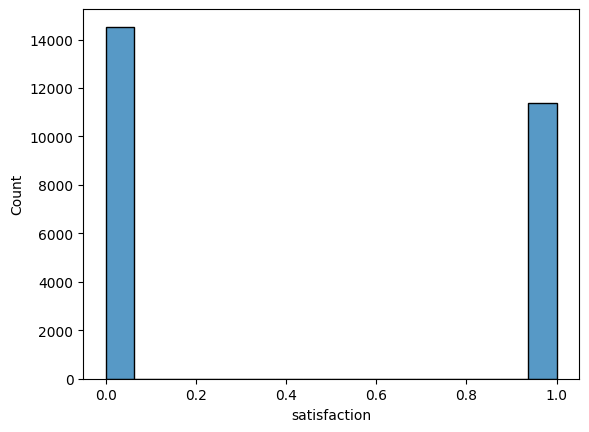

In [21]:
# creating a histplot to see the distribution of the target variable "satisfaction" 
sns.histplot(data=df, x="satisfaction")

In [22]:
# checking the value counts of the target variable "satisfaction" 
df["satisfaction"].value_counts()

satisfaction
0    14528
1    11365
Name: count, dtype: int64

<div style="border: 4px solid #31abc7ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: DISTRIBUTION
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <b>By looking at the histplot and the value counts, it clearly shows that the distribution is healthy</b>. 
    
  </p>

</div>

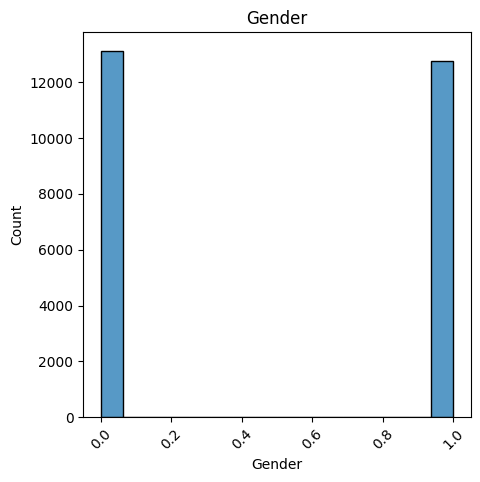

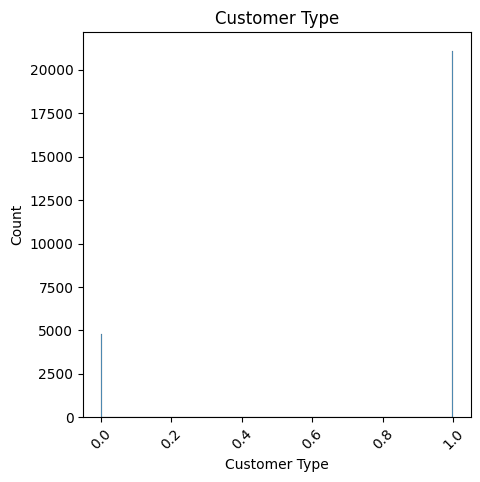

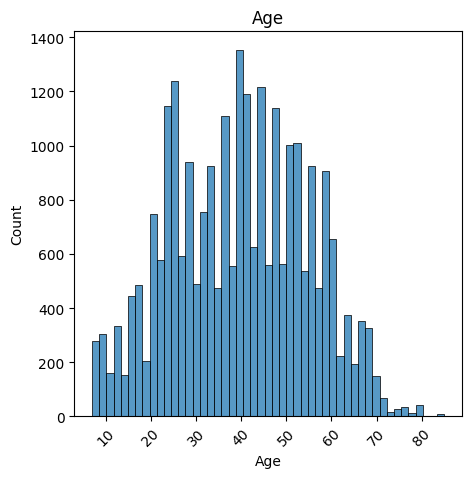

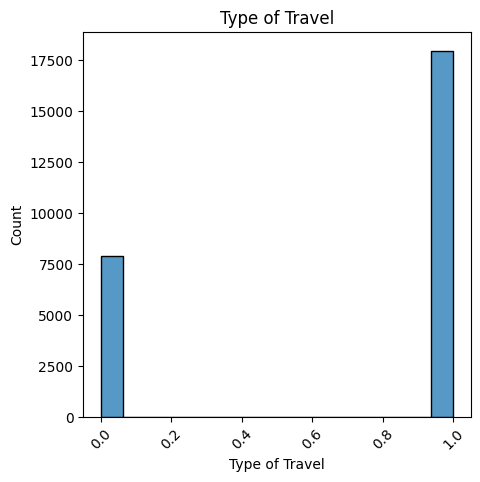

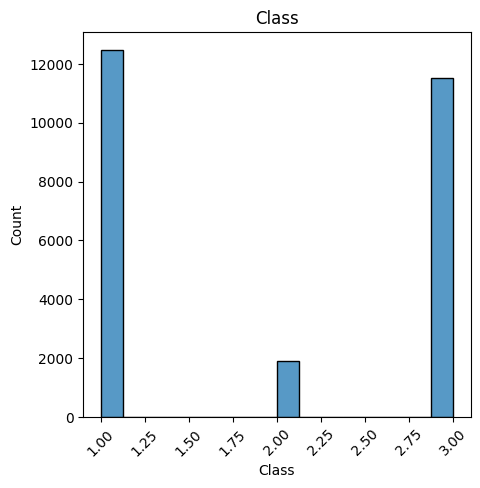

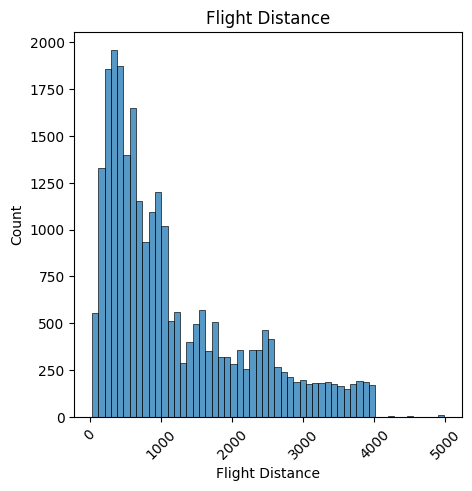

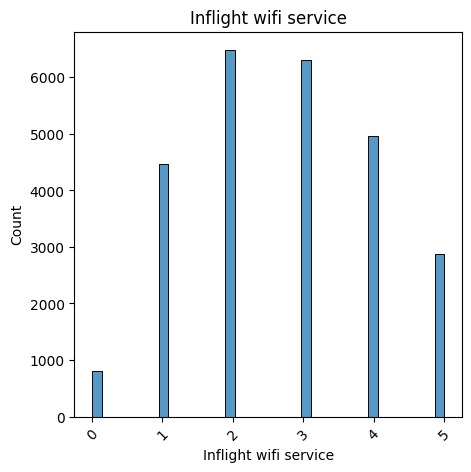

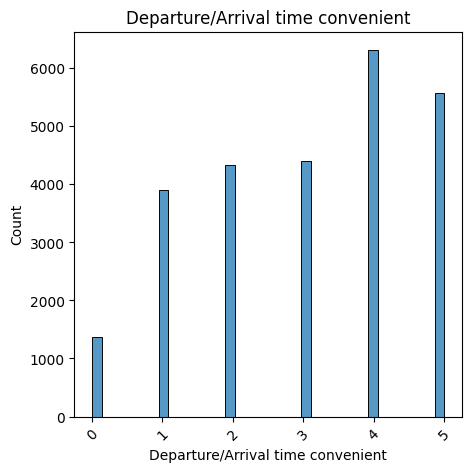

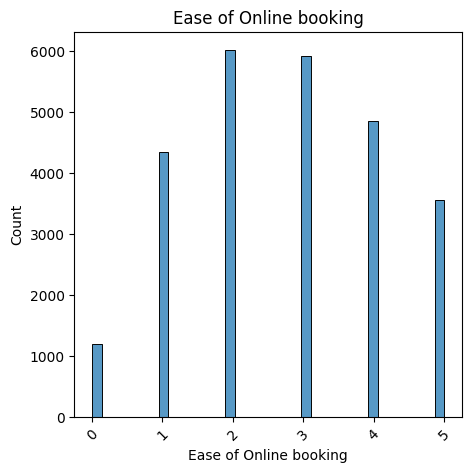

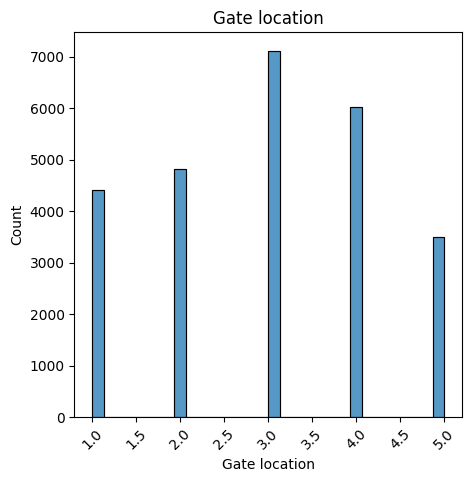

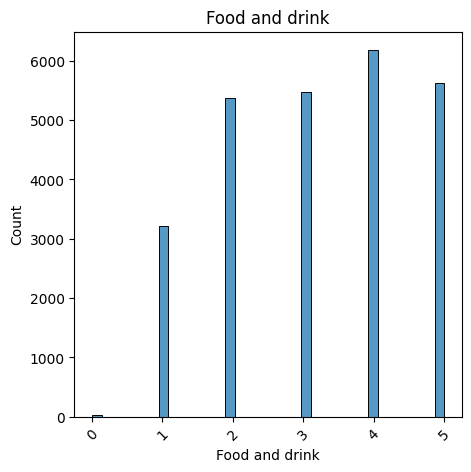

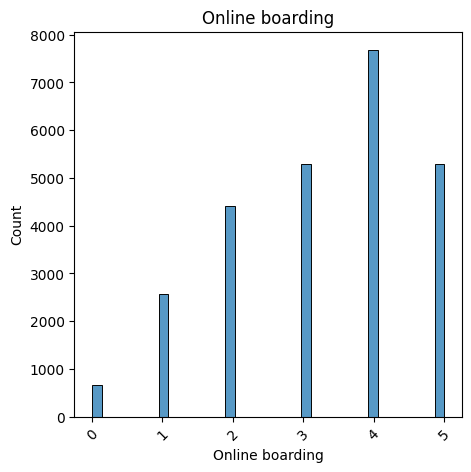

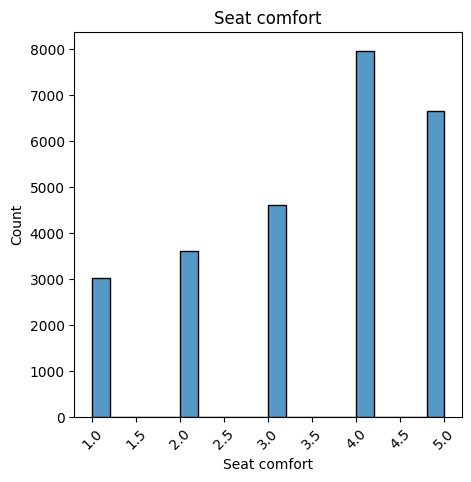

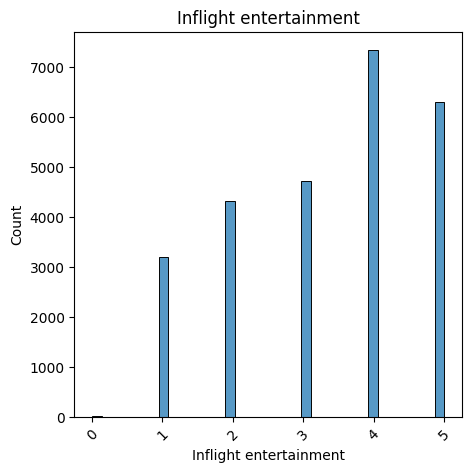

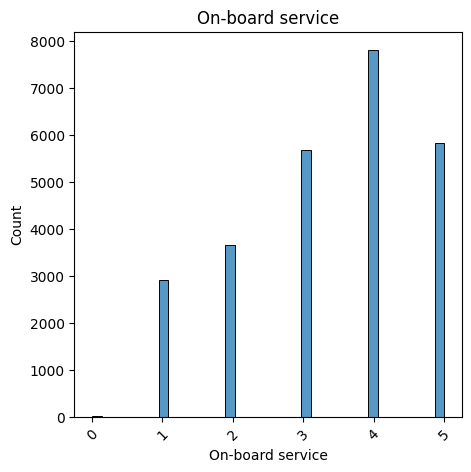

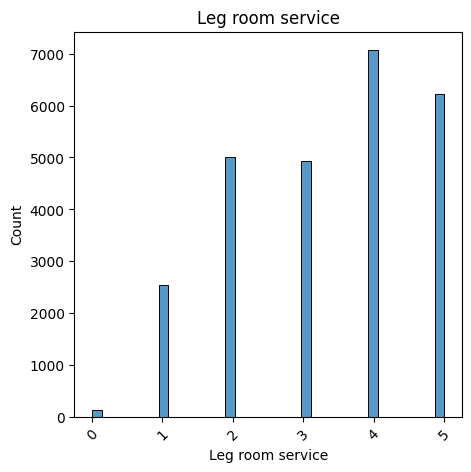

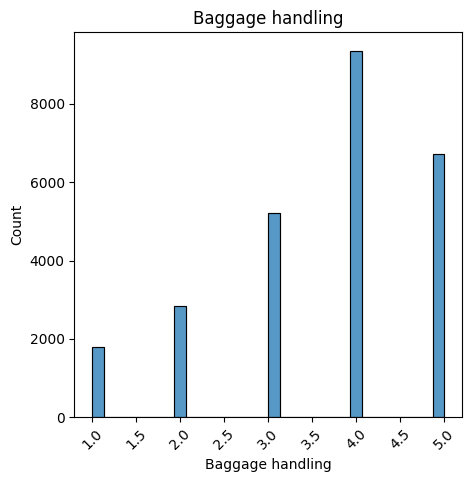

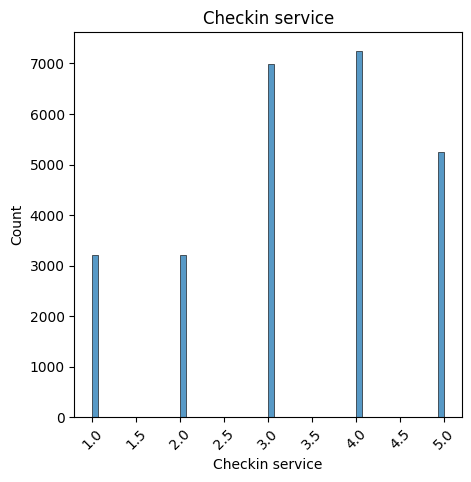

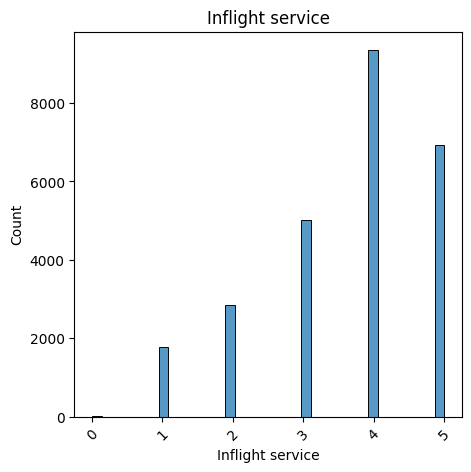

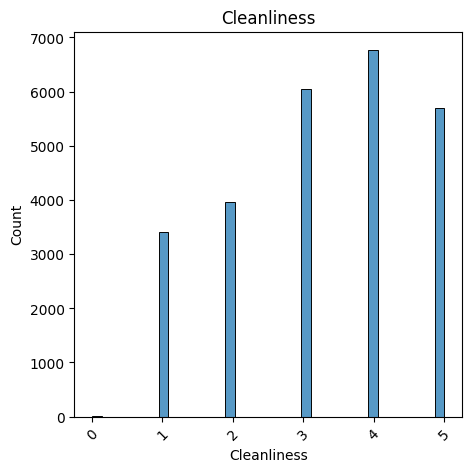

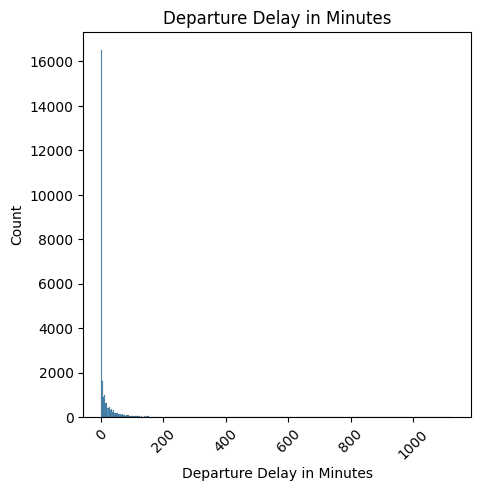

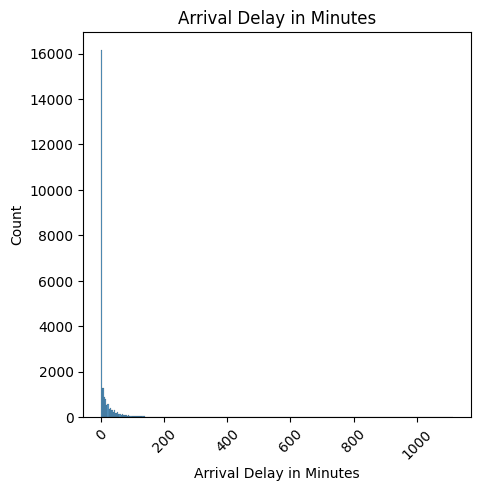

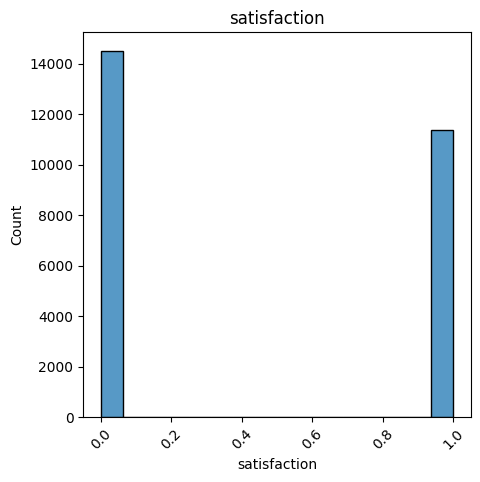

In [23]:
# Now checking visually which columns might afftect the model the most,
# by creating histplots and countplots for columns.

for col in df.columns:
    plt.figure(figsize=(5,5))
    
    if df[col].dtype == "object":
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col)
    
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [24]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("satisfaction", axis=1)

# our target variable is y
y = df["satisfaction"]

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [25]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [26]:
print(X_train.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')


<div style="border: 4px solid #31abc7ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model

  </p>

</div>

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>NOTE! one difference when compared to previous exercise, WE NEED TO SCALE OUR SUPPORT VARIABLES FOR logistic regression!
</b>
</h3>

In [27]:
# initialize the scaler and process X-values
# IN MOST CASES you can experiment with StandardScaler or MinMaxWScaler
# BUT ONLY USE ONE SCALER AT A TIME FOR SUPPORT VARIABLES
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# FIT the scaler only to X-training data
# and only transform the test data with that
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [28]:
# create the model and training it with the data
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model trains without crashing so that's a nice and it means the column are converted properly </li>
 
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Classification error metrics
</b>
</h3>

In [29]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [30]:
# printing the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# getting overall accuracy of the model and printing it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      4428
           1       0.86      0.85      0.86      3340

    accuracy                           0.88      7768
   macro avg       0.88      0.87      0.87      7768
weighted avg       0.88      0.88      0.88      7768


Model overall accuracy: 87.68%


<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model overall accuracy: 86.77% which is good!</li>
    <li>If we need to improve the performance of the model then we need to fine tune tha data handling little more as by seeing the histplots,
    we can remove certain values like 0 from these columns "Food and Drink", "Online boarding", "Inflight entertainment", "Onboard service", "Legroom service" and "Service cleanliness".  </li>
 
  </ul>
</div>



<Axes: >

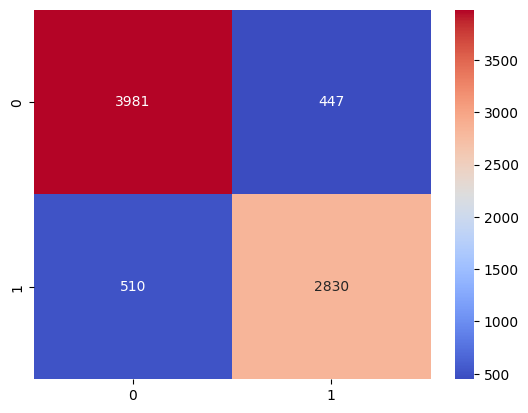

In [31]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g', cmap='coolwarm')


In [32]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.9300027316640432

---

<h3 style='color:orange'>
  <b>Using the model in practice
</b>
</h3>

In [33]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [34]:
# usually in GUI application we save the model-object / variable into a file (by using joblib-module)
# and in the GUI application => we load the saved model from the file
# and use the model just like here below


# map all the variables from the user
# into a Python dictionary
# the variable names have to match with the original dataset
tester_row = {
    'Gender': '0',
    'Customer Type': '1',
    'Age': '54',
    'Type of Travel': '1',
    'Class': '2',
    'Flight Distance': '1000',
    'Inflight wifi service': '3',
    'Departure/Arrival time convenient': '2',
    'Ease of Online booking': '3',
    'Gate location': '2',
    'Food and drink': '5',
    'Online boarding': '4',
    'Seat comfort': '4',
    'Inflight entertainment': '3',
    'On-board service': '3',
    'Leg room service': '4',
    'Baggage handling': '2',
    'Checkin service': '4',
    'Inflight service': '3',
    'Cleanliness': '5',
    'Departure Delay in Minutes': '0', 
    'Arrival Delay in Minutes': '0',          
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

# SINCE WE SCALED our support variables earlier
# WE HAVE TO DO IT HERE AS WELL
tester_row = sc.transform(tester_row)


In [35]:
print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data
labels = ["neutral or dissatisfied", "satisfied"]
print("Is the person satisfied with the service:")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
[[0.15471389 0.84528611]]

Is the person satisfied with the service:
satisfied
-------------------


<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model is performing very well, and the AUC score of <b>0.923</b> which is excellent and clearly confirms that is very better than random guessing. 
    And we are also able to predict the target variable.</li>
 
  </ul>
</div>

---

<div style="border: 4px solid #31abc7ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    CONCLUSION:
  </h2>
  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>When we started building this ML model, the dataset was in rough shape. We went through detailed preprocessing: removing irrelevant columns, transforming values, and more. After filtering, we were left with <strong style="color:#31abc7ff;">25,976 rows and 23 columns</strong>, all of which were numeric, which was very helpful.</li>
    <br>
    <li>There were some <strong style="color:#31abc7ff;">null values</strong> present which were removed to ensure clean data. During data handling, we identified <strong style="color:#31abc7ff;">4 columns</strong> that needed to be treated as binary and <strong style="color:#31abc7ff;">1 column</strong> as ordinal, and these were encoded accordingly.</li>
    <br>
    <li>Training went completely smoothly without any crashes, which also confirmed that all column conversions were done correctly. Earlier in the process, we had mistakenly been encoding columns that should have been left as-is such as <strong style="color:#31abc7ff;">Age</strong>, <strong style="color:#31abc7ff;">Flight Distance</strong>, <strong style="color:#31abc7ff;">Time</strong>, and several others, which was corrected.</li>
    <br>
    <li>The model is performing very well. The <strong style="color:#31abc7ff;">AUC score of 0.923</strong> falls in the Excellent range (> 0.9), clearly confirming that the model is far better than random guessing. We are also successfully able to predict the target variable.</li>
    <br>
    <li>The <strong style="color:#31abc7ff;">overall model accuracy is 86.77%</strong>, which is a strong result for this classification task.</li>
    <br>
    <li>To further improve performance, the data handling can be fine-tuned slightly. Based on the histogram plots, removing <strong style="color:#31abc7ff;">zero (0) values</strong> from the following columns could help: Food and Drink, Online Boarding, Inflight Entertainment, Onboard Service, Legroom Service, and Seat Comfort / Cleanliness.</li>
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #31abc7ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> AI Usage</b>
</h3>
</div>


<h3>
<strong style='color:orange ;'>Yes (for html and style)
 </strong>
</h3>




---